In [1]:
import sys
from pathlib import Path


sys.path.insert(0, str(Path().absolute().parent.parent.parent))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('validation.csv')
df['diff'] = df['flux_v6'] - df['flux_v8']
df['rel_diff'] = df['diff'] / df['flux_v6'] * 100
df = df.sort_values(['date', 'seed', 'val']).copy().reset_index(drop=True)
df

,date,seed,val,rigidity,flux_v8,flux_v6,flux_v8o,diff,rel_diff
0,20111116,72,512,1.080,823.523961,777.158279,830.139987,-46.365682,-5.966054
1,20111116,72,512,1.245,833.858947,813.921050,797.864103,-19.937896,-2.449611
2,20111116,72,512,1.420,767.479708,789.730177,805.771332,22.250469,2.817477
3,20111116,72,512,1.610,744.203670,747.700363,740.495597,3.496693,0.467660
4,20111116,72,512,1.815,669.337939,680.888417,681.355118,11.550477,1.696383
...,...,...,...,...,...,...,...,...,...
6619,20180929,861,65536,7.425,56.333779,56.359773,56.418807,0.025994,0.046121
6620,20180929,861,65536,8.120,44.974460,44.948359,44.965169,-0.026102,-0.058071
6621,20180929,861,65536,8.870,35.918879,35.865312,35.900291,-0.053567,-0.149357
6622,20180929,861,65536,9.680,28.632443,28.624708,28.668594,-0.007734,-0.027020


<Axes: xlabel='rigidity', ylabel='rel_diff'>

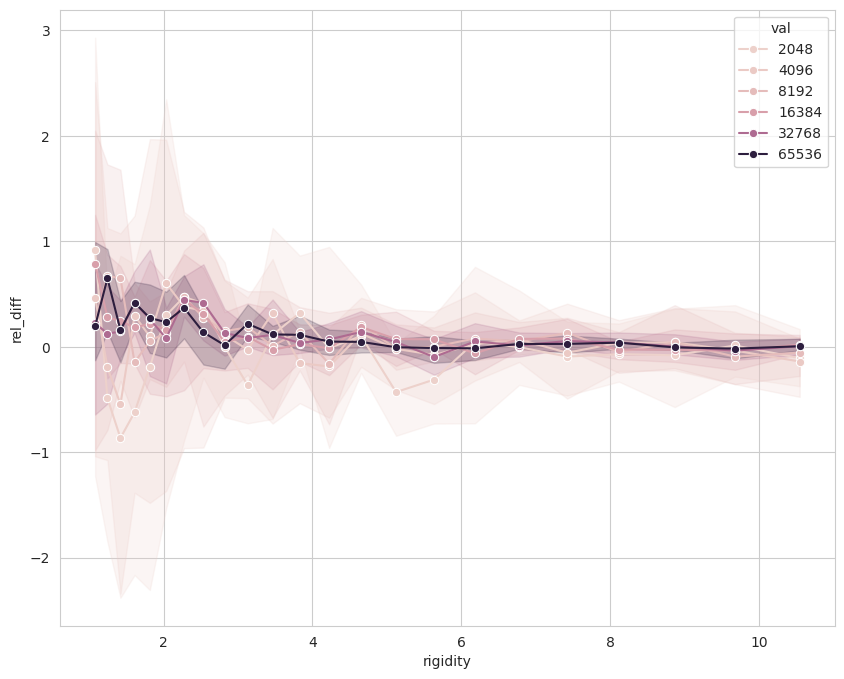

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.lineplot(
    data=df.query('(date == 20111116) & (val > 2000)'),
    x='rigidity',
    y='rel_diff',
    hue='val',
    errorbar=('ci', 100),
    marker='o',
    # palette='muted',
    ax=ax,
)